# Ordinary Kriging
> This code provides an example for implementing kriging interpolation, using a Spherical variogram.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging

## Loading data

In [2]:
# url = "https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/2D_MV_200Wells.csv" # downloaded and saved locally for faster access
url = "./data/2D_MV_200Wells.csv"
mydata = pd.read_csv(url)

# CRITICAL: Convert coordinates to float64
x = mydata['X'].values.astype(np.float64)
y = mydata['Y'].values.astype(np.float64)
z = mydata['porosity'].values.astype(np.float64)

print(f"Data loaded: {len(z)} samples")
print(f"X range: [{x.min():.0f}, {x.max():.0f}]")
print(f"Y range: [{y.min():.0f}, {y.max():.0f}]")
print(f"Porosity range: [{z.min():.4f}, {z.max():.4f}]")


FileNotFoundError: [Errno 2] No such file or directory: './data/2D_MV_200Wells.csv'

/var/folders/b_/785b5fkd03z7drcwj2yt_rwr0000gp/T/ipykernel_23733/549378008.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Data loaded: 200 samples
X range: [25, 3955]
Y range: [35, 3995]
Porosity range: [0.0500, 0.2232]

Grid size: 866 x 872 = 755152 points
Plotting Enabled

Adjusting data for anisotropy...
Initializing variogram model...
Coordinates type: 'euclidean' 

Using 'spherical' Variogram Model
Partial Sill: 0.0008298118563179109
Full Sill: 0.001262525064824657
Range: 2121.0938215172146
Nugget: 0.0004327132085067462 



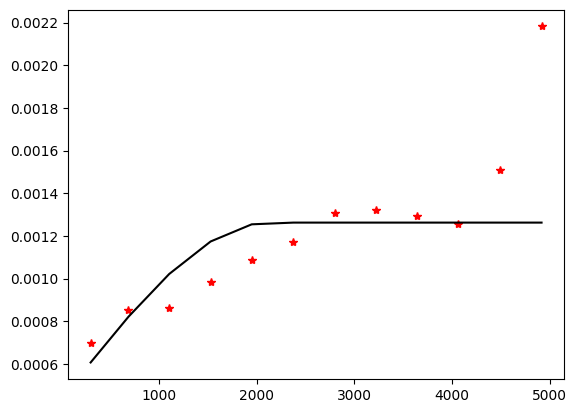

Calculating statistics on variogram model fit...

Kriging object created
Executing Ordinary Kriging...

Kriging completed. Output shape: (872, 866)


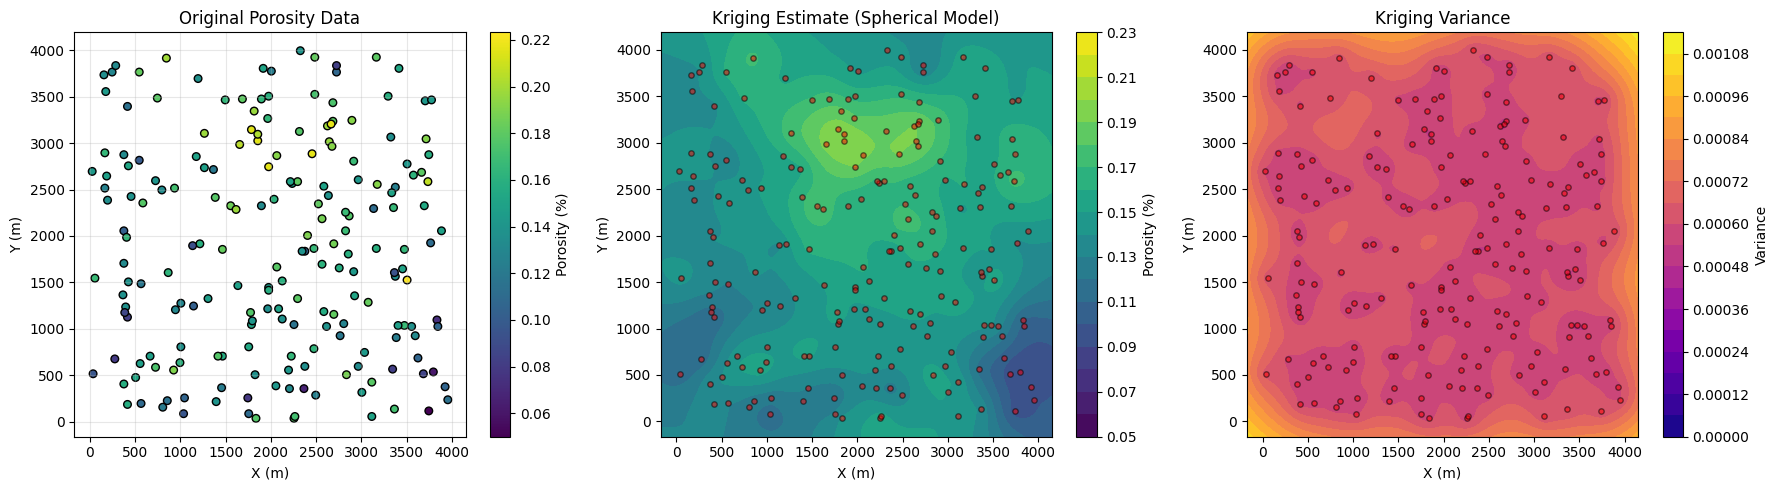

In [ ]:

# ============================================================
# 2. DEFINE KRIGING GRID (MUST ALSO BE FLOAT)
# ============================================================

# Create a grid for interpolation
gridx = np.arange(x.min() - 200, x.max() + 200, 5).astype(np.float64)
gridy = np.arange(y.min() - 200, y.max() + 200, 5).astype(np.float64)

print(f"\nGrid size: {len(gridx)} x {len(gridy)} = {len(gridx) * len(gridy)} points")

# ============================================================
# 3. CREATE ORDINARY KRIGING OBJECT
# ============================================================

OK = OrdinaryKriging(
    x, y, z,
    variogram_model='spherical',
    verbose=True,
    enable_plotting=True,
    nlags=12,
    weight=True
)

print("\nKriging object created")

# ============================================================
# 4. EXECUTE KRIGING
# ============================================================

z_kriged, ss_kriged = OK.execute('grid', gridx, gridy)

print(f"Kriging completed. Output shape: {z_kriged.shape}")

# ============================================================
# 5. VISUALIZE RESULTS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Original data
sc1 = axes[0].scatter(x, y, c=z, cmap='viridis', s=30, edgecolor='black')
axes[0].set_xlabel('X (m)')
axes[0].set_ylabel('Y (m)')
axes[0].set_title('Original Porosity Data')
axes[0].grid(True, alpha=0.3)
plt.colorbar(sc1, ax=axes[0], label='Porosity (%)')

# Plot 2: Kriging estimate
im2 = axes[1].contourf(gridx, gridy, z_kriged, levels=20, cmap='viridis')
axes[1].scatter(x, y, c='red', s=15, alpha=0.5, edgecolor='black')
axes[1].set_xlabel('X (m)')
axes[1].set_ylabel('Y (m)')
axes[1].set_title('Kriging Estimate (Spherical Model)')
plt.colorbar(im2, ax=axes[1], label='Porosity (%)')

# Plot 3: Kriging variance
im3 = axes[2].contourf(gridx, gridy, ss_kriged, levels=20, cmap='plasma')
axes[2].scatter(x, y, c='red', s=15, alpha=0.5, edgecolor='black')
axes[2].set_xlabel('X (m)')
axes[2].set_ylabel('Y (m)')
axes[2].set_title('Kriging Variance')
plt.colorbar(im3, ax=axes[2], label='Variance')

plt.tight_layout()
plt.savefig('pykrige_results.png', dpi=150, bbox_inches='tight')
plt.show()

---

In [ ]:

print("\n" + "=" * 60)
print("PREDICTING AT SAMPLED LOCATIONS")
print("=" * 60)

# Predict at all sampled locations
z_pred, z_pred_var = OK.execute('points', x, y)

# Calculate errors
errors = z - z_pred
abs_errors = np.abs(errors)
squared_errors = errors ** 2



PREDICTING AT SAMPLED LOCATIONS
Executing Ordinary Kriging...



## Error Statistics

In [ ]:

print("\n" + "-" * 40)
print("ERROR STATISTICS (Original Porosity Scale)")
print("-" * 40)
print(f"Mean Error (ME):           {errors.mean():.8f} %")
print(f"Mean Absolute Error (MAE): {abs_errors.mean():.6f} %")
print(f"Mean Squared Error (MSE):  {squared_errors.mean():.8f}")
print(f"Root Mean Squared Error:   {np.sqrt(squared_errors.mean()):.6f} %")
print(f"Variance of Errors:        {errors.var():.8f}")
print(f"Min Error:                 {errors.min():.8f} %")
print(f"Max Error:                 {errors.max():.8f} %")

# Check if exact interpolation worked
max_abs_error = abs_errors.max()
if max_abs_error < 1e-6:
    print("\n✓ EXACT INTERPOLATION: All errors are effectively zero (numerical precision)")
else:
    print(f"\n WARNING: Maximum absolute error is {max_abs_error:.2e}")


----------------------------------------
ERROR STATISTICS (Original Porosity Scale)
----------------------------------------
Mean Error (ME):           -0.00000000 %
Mean Absolute Error (MAE): 0.000000 %
Mean Squared Error (MSE):  0.00000000
Root Mean Squared Error:   0.000000 %
Variance of Errors:        0.00000000
Min Error:                 -0.00000000 %
Max Error:                 0.00000000 %

✓ EXACT INTERPOLATION: All errors are effectively zero (numerical precision)
